In [1]:
# Required for debug only. If you have data_fast_insights installed, you can delete this cell.
import sys
from pathlib import Path
import os

sys.path.append(str(Path(os.getcwd()).parent.parent))
sys.path.append(str(Path(os.getcwd()).parent))

In [2]:
%config InlineBackend.figure_format = 'svg'

Getting the data

In [3]:
import pandas as pd
from sklearn import datasets
import matplotlib.pyplot as plt

from data_fast_insights import BinaryDependenceModelData
import data_fast_insights.calculations as calc

from data_fast_insights.plotting import plot_segments_basic_info, create_feature_segments_plot_plotly

In [4]:
raw_data = datasets.fetch_california_housing()
# print(raw_data['DESCR'])

In [5]:
df = pd.DataFrame(raw_data['data'], columns=raw_data['feature_names'])
df['MedianHouseValue'] = raw_data['target']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedianHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Using Data Fast Insights

Initializing model data

In [6]:
dmd = BinaryDependenceModelData(
    base_data=df,
    cat_cols=None,
    num_cols={'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'},
    y_name='MedianHouseValue',
    y_quantile=0.5)

Getting bins for numeric variables, optimizing for Information Value. 

In [7]:
num_bins = calc.make_bins(model_data=dmd)

Converting variables

In [8]:
dmd.convert_to_binary(bins=num_bins)

Calculating group importance and other metrics

In [9]:
res = calc.calculate_dependence(model_data=dmd)

Getting data about segments (dataframe is sorted by importance)

In [10]:
# print(res[res['perc_of_total'] > 5][:3][['low_perc', 'base_col']])
res[res['perc_of_total'] > 5].head(4).round(1)

,count,low_count,low_perc,high_perc,perc_of_total,target_delta,group_importance,base_col,base_breaks,base_range,base_cats,target_mean,target_median
"Latitude_[38.9,inf)",1118,1063,95.1,4.9,5.4,-51.3,-0.1,Latitude,"[32.8, 33.6, 33.9, 34.1, 34.5, 37, 37.8, 38.4,...","[np.float64(32.54), np.float64(41.95)]",,1.0,0.9
"MedInc_[-inf,2.1)",2857,2525,88.4,11.6,13.8,-45.2,-0.1,MedInc,"[2.1, 2.4, 2.6, 2.8, 3.2, 3.5, 3.8, 4.1, 4.5, ...","[np.float64(0.4999), np.float64(15.0001)]",,1.1,0.9
"AveOccup_[3.9,inf)",2017,1680,83.3,16.7,9.8,-30.3,-0.1,AveOccup,"[2, 2.1, 2.3, 2.8, 3.1, 3.3, 3.5, 3.9, inf]","[np.float64(0.6923076923076923), np.float64(12...",,1.4,1.4
"MedInc_[2.1,2.4)",1506,1252,83.1,16.9,7.3,-36.6,-0.1,MedInc,"[2.1, 2.4, 2.6, 2.8, 3.2, 3.5, 3.8, 4.1, 4.5, ...","[np.float64(0.4999), np.float64(15.0001)]",,1.3,1.2


#### Plotting basic info about features segments

With increasing the occupancy number house value drops

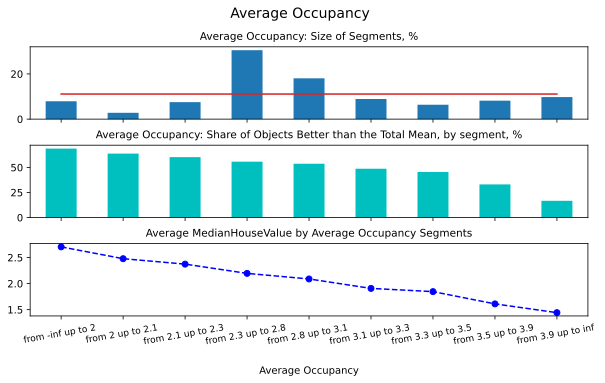

In [11]:
f = plot_segments_basic_info(
    model_data=dmd, res_low_df=res, base_feature_name='AveOccup', base_feature_rename='Average Occupancy')

There is a significant drop of house value in blocks 
located at Longitude from -121 up to -119 (not including -119), which requires further research.

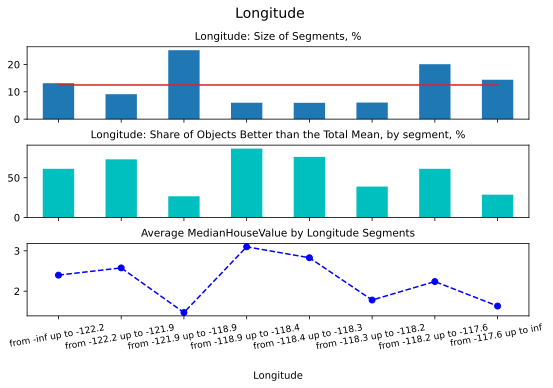

In [12]:
f = plot_segments_basic_info(
    model_data=dmd, res_low_df=res, base_feature_name='Longitude')
plt.gcf().set_size_inches(9.0, 5.5)

Blocks with residents having highest income contain the most highly valued houses.

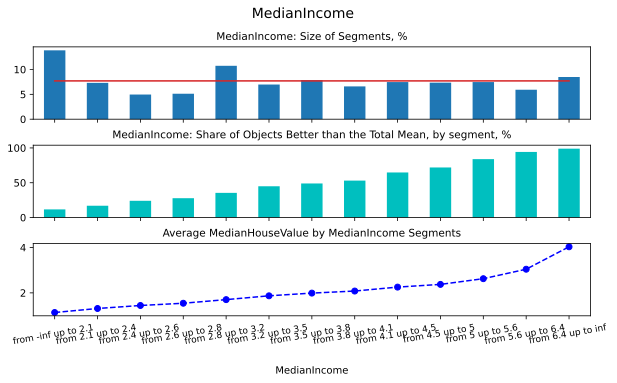

In [13]:
f = plot_segments_basic_info(
    model_data=dmd, res_low_df=res, base_feature_name='MedInc', base_feature_rename='MedianIncome')

In [14]:
create_feature_segments_plot_plotly(
    info_df=res
)